<h1 style="color:#237227;">E-Commerce Customer Churn Analysis</h1>

<h2 style="color:#519A66;">1. Import Libraries</h2>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import math as m
import datetime
import statistics

# Statistical analysis
from scipy import stats

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image, ImageDraw

<h2 style="color:#519A66;">2. Upload Data</h2>

In [3]:
df = pd.read_csv("customer churn.csv")

<h2 style="color:#519A66;">3. Data Understanding</h2>

In [4]:
df.head()

,Customer_ID,Gender,Region,Subscription_Plan,Payment_Method,Age,Days_Since_Last_Login,Customer_Service_Calls,Monthly_Spend,Churn
0,10001,Male,East,Basic,PayPal,27.0,27,1,61.08,0
1,10002,Unknown,West,Pro,PayPal,55.0,146,2,73.09,0
2,10003,Female,West,Pro,E-Wallet,NaN,147,2,116.30,1
3,10004,Female,south,Basic,Credit Card,NaN,34,1,0.58,1
4,10005,Male,North,Basic,Crypto,30.0,146,3,46.35,1


In [5]:
df.shape

(10300, 10)

In [6]:
df.dtypes

Customer_ID                 int64
Gender                     object
Region                     object
Subscription_Plan          object
Payment_Method             object
Age                       float64
Days_Since_Last_Login       int64
Customer_Service_Calls      int64
Monthly_Spend             float64
Churn                       int64
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10300 entries, 0 to 10299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             10300 non-null  int64  
 1   Gender                  10300 non-null  object 
 2   Region                  10300 non-null  object 
 3   Subscription_Plan       10300 non-null  object 
 4   Payment_Method          9575 non-null   object 
 5   Age                     9267 non-null   float64
 6   Days_Since_Last_Login   10300 non-null  int64  
 7   Customer_Service_Calls  10300 non-null  int64  
 8   Monthly_Spend           9786 non-null   float64
 9   Churn                   10300 non-null  int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 804.8+ KB


In [8]:
# Missing values (Payment_Method, Age, Monthly_Spend) 

In [9]:
df.nunique()

Customer_ID               10000
Gender                        4
Region                        8
Subscription_Plan             6
Payment_Method                4
Age                          73
Days_Since_Last_Login       180
Customer_Service_Calls       11
Monthly_Spend              6768
Churn                         2
dtype: int64

In [10]:
categorical_columns = [
    'Gender',
    'Region',
    'Subscription_Plan',
    'Payment_Method',
    'Churn'
]
for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())


Gender:
['Male' 'Unknown' 'Female' 'Non-Binary']

Region:
['East' 'West' 'south' 'North' 'South' 'north' 'east' 'west']

Subscription_Plan:
['Basic' 'Pro' 'BASIC' 'PLUS' 'Plus' 'PRO']

Payment_Method:
['PayPal' 'E-Wallet' 'Credit Card' 'Crypto' nan]

Churn:
[0 1]


In [11]:
# Capitalizationin Region & Subscription_Plan

In [12]:
df.describe()

,Customer_ID,Age,Days_Since_Last_Login,Customer_Service_Calls,Monthly_Spend,Churn
count,10300.000000,9267.000000,10300.000000,10300.000000,9786.000000,10300.000000
mean,14859.237864,33.521852,89.449903,1.787379,300.093737,0.762039
std,2959.197492,11.514686,52.088510,1.363470,4733.134612,0.425856
min,10001.000000,-10.000000,0.000000,-1.000000,-10.000000,0.000000
25%,12275.750000,26.000000,44.000000,1.000000,26.275000,1.000000
50%,14850.500000,33.000000,90.000000,2.000000,66.355000,1.000000
75%,17425.250000,40.000000,135.000000,3.000000,115.915000,1.000000
max,20000.000000,150.000000,179.000000,9.000000,99999.990000,1.000000


In [13]:
# Min Age= -10?! / Max Age = 150?! 
# Min Customer_Service_Calls = -1 ?!
# Min Monthly_Spend = -10 ?!   / Large Gap between SD & Mean --> Outlier / Max = 99999.99 ?!

In [13]:
import pandas as pd

numeric_cols = [
    'Customer_ID',
    'Age',
    'Days_Since_Last_Login',
    'Customer_Service_Calls',
    'Monthly_Spend'
]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"\n{col}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of Outliers: {len(outliers)}")


Customer_ID
Lower Bound: 4551.50
Upper Bound: 25149.50
Number of Outliers: 0

Age
Lower Bound: 5.00
Upper Bound: 61.00
Number of Outliers: 89

Days_Since_Last_Login
Lower Bound: -92.50
Upper Bound: 271.50
Number of Outliers: 0

Customer_Service_Calls
Lower Bound: -2.00
Upper Bound: 6.00
Number of Outliers: 24

Monthly_Spend
Lower Bound: -108.19
Upper Bound: 250.38
Number of Outliers: 39


<h2 style="color:#519A66;">4. Data Pre-processing</h2>

In [14]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 300


In [15]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True) #Resets DataFrame index after removing duplicate rows

# Check again
print("After removing duplicates:", df.duplicated().sum())

After removing duplicates: 0


In [16]:
# Check new dataset shape
print("New dataset shape:", df.shape)

New dataset shape: (10000, 10)


In [17]:
# Check missing values
missing_values = df.isnull().sum()
print(missing_values)

Customer_ID                 0
Gender                      0
Region                      0
Subscription_Plan           0
Payment_Method            700
Age                       995
Days_Since_Last_Login       0
Customer_Service_Calls      0
Monthly_Spend             500
Churn                       0
dtype: int64


### Handling missing Payment_Method 

In [18]:
# Replace missing payment methods with "Unknown" or "Mode"
df['Payment_Method'] = df['Payment_Method'].fillna('Unknown')

In [19]:
print(df['Payment_Method'].value_counts())

Payment_Method
Crypto         2365
PayPal         2324
Credit Card    2310
E-Wallet       2301
Unknown         700
Name: count, dtype: int64


### Handling missing & invalid ages

In [20]:
# calculated the median using Age between 18 & 100 to avoid including invalid ages in the median calculation.
# Replace invalid ages with NaN
df.loc[(df['Age'] < 5) | (df['Age'] > 100), 'Age'] = np.nan

# Calculate median using only valid ages (NaNs are automatically ignored)
age_median = df['Age'].median()

# Fill invalid/missing ages with the median
df['Age'] = df['Age'].fillna(age_median)

In [21]:
print("Missing Age values after imputation:", df['Age'].isnull().sum())

Missing Age values after imputation: 0


## Handling Max Age = 150 

In [22]:
df.loc[df['Age'] == 150 , 'Age'] = np.nan

spend_median = df['Age'].median()

df['Age'] = df['Age'].fillna(spend_median)

In [23]:
print(df['Age'].describe())

count    10000.000000
mean        33.420500
std          9.389148
min          5.000000
25%         28.000000
50%         33.000000
75%         39.000000
max         70.000000
Name: Age, dtype: float64


### Handling missing Monthly_Spend 

In [24]:
# Fill missing Monthly Spend values with the median
spend_median = df['Monthly_Spend'].median()
df['Monthly_Spend'] = df['Monthly_Spend'].fillna(spend_median)

print("Missing Monthly Spend after imputation:",df['Monthly_Spend'].isnull().sum())

Missing Monthly Spend after imputation: 0


In [25]:
print(df['Monthly_Spend'].describe())

count    10000.000000
mean       185.029708
std       3312.987566
min        -10.000000
25%         28.465000
50%         66.365000
75%        112.835000
max      99999.990000
Name: Monthly_Spend, dtype: float64


### Handling Monthly_Spend < 0

In [26]:
# Replace all negative values with NaN
df.loc[df['Monthly_Spend'] < 0, 'Monthly_Spend'] = np.nan

# Fill missing and invalid values with the median
df['Monthly_Spend'] = df['Monthly_Spend'].fillna(
    df['Monthly_Spend'].median()
)

### Handling Max Monthly_Spend = 99999.99 

In [27]:
df.loc[df['Monthly_Spend'] == 99999.99, 'Monthly_Spend'] = np.nan

spend_median = df['Monthly_Spend'].median()

df['Monthly_Spend'] = df['Monthly_Spend'].fillna(spend_median)

In [28]:
print(df['Monthly_Spend'].describe())

count    10000.000000
mean        75.469273
std         57.943481
min          0.000000
25%         29.407500
50%         66.365000
75%        112.465000
max        311.390000
Name: Monthly_Spend, dtype: float64


### Handling Customer_Service_Calls < 0

In [29]:
# Replace all negative values with NaN
df.loc[df['Customer_Service_Calls'] < 0, 'Customer_Service_Calls'] = np.nan

# Fill missing values with the median
df['Customer_Service_Calls'] = df['Customer_Service_Calls'].fillna(
    df['Customer_Service_Calls'].median()
)

In [30]:
print(df['Customer_Service_Calls'].describe())

count    10000.000000
mean         1.806000
std          1.349943
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          9.000000
Name: Customer_Service_Calls, dtype: float64


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             10000 non-null  int64  
 1   Gender                  10000 non-null  object 
 2   Region                  10000 non-null  object 
 3   Subscription_Plan       10000 non-null  object 
 4   Payment_Method          10000 non-null  object 
 5   Age                     10000 non-null  float64
 6   Days_Since_Last_Login   10000 non-null  int64  
 7   Customer_Service_Calls  10000 non-null  float64
 8   Monthly_Spend           10000 non-null  float64
 9   Churn                   10000 non-null  int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 781.4+ KB


### Standardize Region capitalization

In [32]:
# Standardize Region capitalization
df['Region'] = df['Region'].str.title()

# Check the result
print(df['Region'].value_counts())

Region
South    2534
East     2509
West     2503
North    2454
Name: count, dtype: int64


### Standardize Subscription_Plan capitalization

In [33]:
df['Subscription_Plan'] = df['Subscription_Plan'].str.title()
print(df['Subscription_Plan'].value_counts())

Subscription_Plan
Basic    4851
Pro      3125
Plus     2024
Name: count, dtype: int64


In [34]:
df.describe() 

,Customer_ID,Age,Days_Since_Last_Login,Customer_Service_Calls,Monthly_Spend,Churn
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,15000.50000,33.420500,89.368500,1.806000,75.469273,0.763400
std,2886.89568,9.389148,52.135828,1.349943,57.943481,0.425016
min,10001.00000,5.000000,0.000000,0.000000,0.000000,0.000000
25%,12500.75000,28.000000,44.000000,1.000000,29.407500,1.000000
50%,15000.50000,33.000000,90.000000,2.000000,66.365000,1.000000
75%,17500.25000,39.000000,135.000000,3.000000,112.465000,1.000000
max,20000.00000,70.000000,179.000000,9.000000,311.390000,1.000000


<h2 style="color:#519A66;">5. Data Visualization</h2>

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             10000 non-null  int64  
 1   Gender                  10000 non-null  object 
 2   Region                  10000 non-null  object 
 3   Subscription_Plan       10000 non-null  object 
 4   Payment_Method          10000 non-null  object 
 5   Age                     10000 non-null  float64
 6   Days_Since_Last_Login   10000 non-null  int64  
 7   Customer_Service_Calls  10000 non-null  float64
 8   Monthly_Spend           10000 non-null  float64
 9   Churn                   10000 non-null  int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 781.4+ KB


In [36]:
# Churn Distribution
print(df['Churn'].value_counts())

print("\nChurn Percentage:")
print((df['Churn'].value_counts(normalize=True) * 100))

Churn
1    7634
0    2366
Name: count, dtype: int64

Churn Percentage:
Churn
1    76.34
0    23.66
Name: proportion, dtype: float64


In [37]:
#feature Engineering (Customer Segmentation)
df['Login_Activity'] = pd.cut(
    df['Days_Since_Last_Login'],
    bins=[-1, 30, 90, float('inf')], #inf = infinity
    labels=['Active', 'At Risk', 'Inactive']
)

In [38]:
print(df['Login_Activity'].value_counts())

Login_Activity
Inactive    4956
At Risk     3292
Active      1752
Name: count, dtype: int64


<h3 style="color:#CC3A63;">What does the customer base split look like: churned vs retained?</h3>

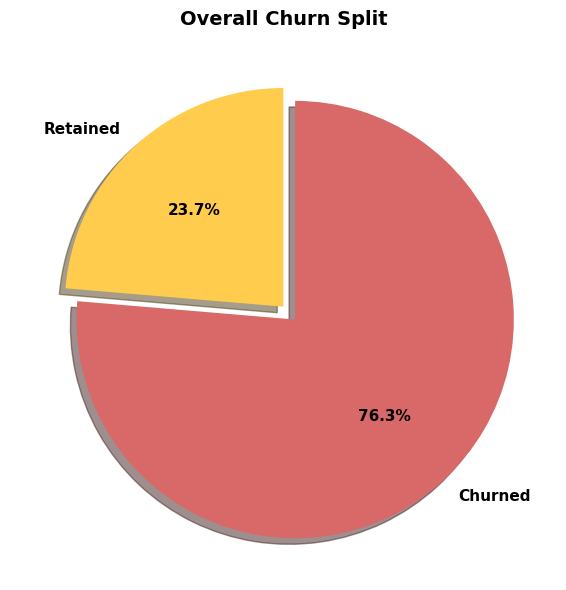

In [39]:
import matplotlib.pyplot as plt

churn_counts = df['Churn'].value_counts().sort_index()
labels = ['Retained', 'Churned']
colors = ['#FFCC4D', '#D96868']

# Pull out the larger slice, like "Python" in the reference image
explode = [0.08 if v == churn_counts.max() else 0 for v in churn_counts.values]

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    churn_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

plt.title('Overall Churn Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
# 76.3% of the 10,000 customers in this dataset have churned, versus 23.7% retained.
# That's a heavily imbalanced base

<h3 style="color:#CC3A63;">Does customer activity level affect churn ?</h3>

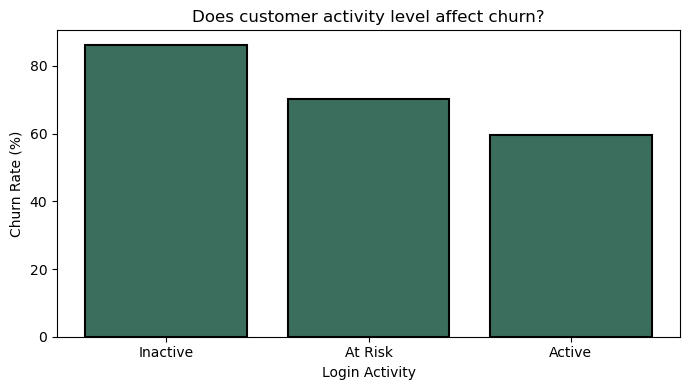

In [41]:
churn_by_activity_level = (
    df.groupby('Login_Activity')['Churn']
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4));

plt.bar(
    churn_by_activity_level.index,
    churn_by_activity_level.values,
    color= '#3C6E5E',
    edgecolor='black',
    linewidth=1.5
)

plt.title('Does customer activity level affect churn?')
plt.xlabel('Login Activity')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

In [42]:
# clear positive relationship bet inactive & churn
# Less active customers are more likely to churn

<h3 style="color:#CC3A63;">Does time since last login matter, or is it a cliff?</h3>

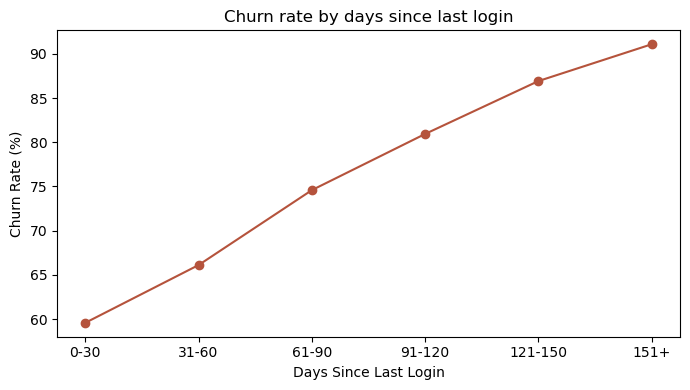

In [43]:
bins = [-1, 30, 60, 90, 120, 150, 200]
labels = ['0-30', '31-60', '61-90', '91-120', '121-150', '151+']
df['days_bucket'] = pd.cut(df['Days_Since_Last_Login'], bins=bins, labels=labels)

churn_by_days = (
    df.groupby('days_bucket', observed=True)['Churn']
      .mean()
      .mul(100)
      .round(2)
)

plt.figure(figsize=(7, 4))
plt.plot(churn_by_days.index, churn_by_days.values, marker='o', color='#B5533C')
plt.title('Churn rate by days since last login')
plt.xlabel('Days Since Last Login')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

In [44]:
# clear positive Relationship between login inactivity and churn.

<h3 style="color:#CC3A63;">Does payment method affect customer churn?</h3>

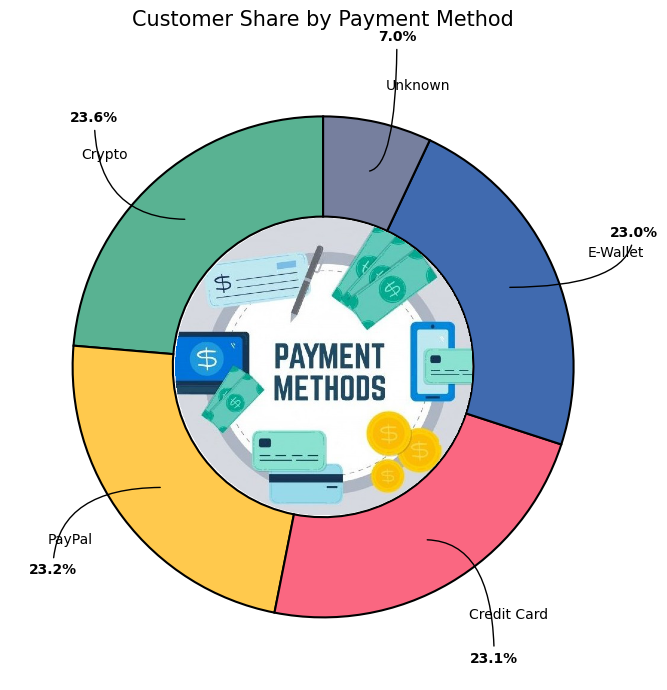

In [45]:
# 1. Count Payment Methods
payment_counts = df['Payment_Method'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts = ax.pie(
    payment_counts.values,
    labels=payment_counts.index,
    startangle=90,

    colors=[
        '#59B292',
        '#FFC94D',
        '#FA6781',
        '#406AAF',
        '#767F9E'
    ],

    wedgeprops={
        'width': 0.4,
        'edgecolor': 'black',
        'linewidth': 1.5
    },

    labeldistance=1.15
)

# 4. Add Percentages Outside Donut
total = payment_counts.sum()

for wedge, value in zip(wedges, payment_counts.values):

    # Calculate percentage
    percentage = value / total * 100

    # Find middle angle of each slice
    angle = (wedge.theta1 + wedge.theta2) / 2

    # Convert angle to radians
    angle_rad = np.deg2rad(angle)

    # Coordinates on donut
    x = np.cos(angle_rad)
    y = np.sin(angle_rad)

    # Add percentage outside
    ax.annotate(
        f'{percentage:.1f}%',
        
        xy=(x * 0.8, y * 0.8),

        xytext=(x * 1.35, y * 1.35),

        ha='center',
        va='center',

        fontsize=10,
        fontweight='bold',

        arrowprops=dict(
            arrowstyle='-',
            connectionstyle='angle3'
        )
    )

# 5. Load Payment Methods Image
logo = Image.open('payment-methods.jpg').convert('RGBA')

# 6. Crop Image to Square
size = min(logo.size)

left = (logo.width - size) // 2
top = (logo.height - size) // 2

logo = logo.crop(
    (
        left,
        top,
        left + size,
        top + size
    )
)

# 7. Make Image Circular
mask = Image.new(
    'L',
    logo.size,
    0
)

draw = ImageDraw.Draw(mask)

draw.ellipse(
    (0, 0, logo.width, logo.height),
    fill=255
)

logo.putalpha(mask)

# 8. Convert Image to NumPy
logo_array = np.array(logo)

# 9. Put Image in Donut Center
imagebox = OffsetImage(
    logo_array,
    zoom=0.43
)

ab = AnnotationBbox(
    imagebox,
    (0, 0),
    frameon=False,
    box_alignment=(0.5, 0.5)
)

ax.add_artist(ab)

# 10. Title
ax.set_title(
    'Customer Share by Payment Method',
    fontsize=15,
    pad=20
)

ax.set_aspect('equal')

plt.tight_layout()

plt.show()

In [46]:
# Churn rates are very similar across payment methods,
# small difference between the highest and lowest rates
# weak relationship between payment method and churn.

<h3 style="color:#CC3A63;">Which subscription plan has the highest churn rate?</h3>

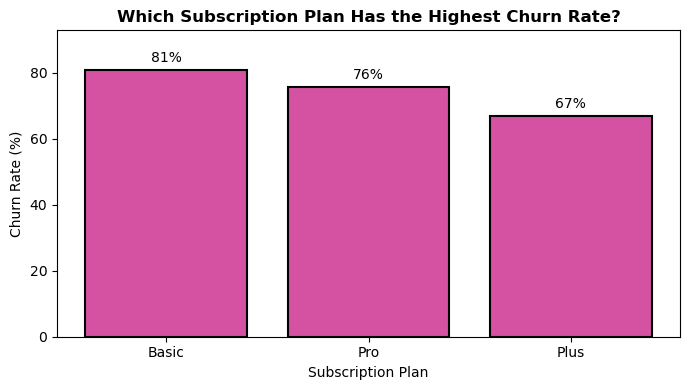

In [47]:
import matplotlib.pyplot as plt

churn_by_plan = (
    df.groupby('Subscription_Plan')['Churn']
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))
bars = plt.bar(churn_by_plan.index, churn_by_plan.values, color='#D552A3',
                edgecolor='black',
                linewidth=1.5)

# Add value labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (height * 0.02),
        f'{height:.0f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Which Subscription Plan Has the Highest Churn Rate?', fontsize=12, fontweight='bold')
plt.xlabel('Subscription Plan')
plt.ylabel('Churn Rate (%)')

plt.ylim(0, max(churn_by_plan.values) * 1.15)
plt.tight_layout()
plt.show()

In [48]:
# The Basic plan has the highest churn rate at 80%, while the Plus plan has the lowest at 67%
# customers on the Basic plan are more likely to churn compared with customers on the other subscription plans

<h3 style="color:#CC3A63;">Do customers with more customer service calls churn more?</h3>

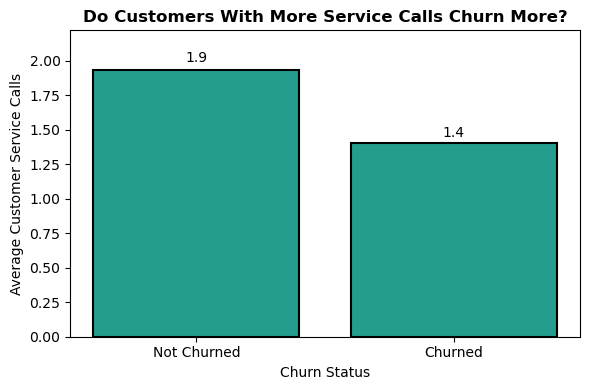

In [49]:
import matplotlib.pyplot as plt

calls_by_churn = (
    df.groupby('Churn')['Customer_Service_Calls']
      .mean()
      .round(2)
      .sort_values(ascending=False)
)

plt.figure(figsize=(6, 4))
bars = plt.bar(
    ['Not Churned', 'Churned'],
    calls_by_churn.values,
    color='#249D8F',
    edgecolor='black',
    linewidth=1.5
)

# Add value labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (height * 0.02),
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Do Customers With More Service Calls Churn More?', fontsize=12, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Average Customer Service Calls')

plt.ylim(0, max(calls_by_churn.values) * 1.15)
plt.tight_layout()
plt.show()

In [50]:
# Churned customers have a higher average number of customer service calls (1.90) than non-churned customers (1.40)
# positive relationship between service calls and churn

<h3 style="color:#CC3A63;">Does monthly spending differ between churned and non-churned customers?</h3>

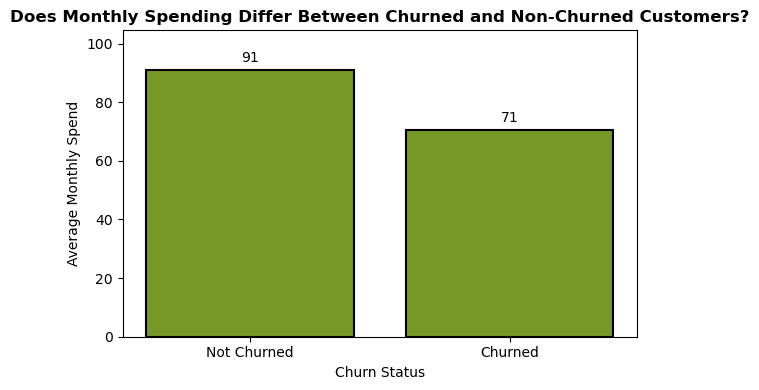

In [51]:
import matplotlib.pyplot as plt

spend_by_churn = (
    df.groupby('Churn')['Monthly_Spend']
      .mean()
      .round(2)
)

plt.figure(figsize=(6, 4))

bars = plt.bar(
    ['Not Churned', 'Churned'],
    spend_by_churn.values,
    color='#769826',
    edgecolor='black',
    linewidth=1.5
)

# Add value labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (height * 0.02),
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Does Monthly Spending Differ Between Churned and Non-Churned Customers?',
          fontsize=12, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Average Monthly Spend')

# Give headroom above the tallest bar so labels don't get clipped
plt.ylim(0, max(spend_by_churn.values) * 1.15)

plt.tight_layout()
plt.show()

In [52]:
# Churned customers have a lower average monthly spend (71) than non-churned customers (91)
# negative relationship between monthly spending and churn.

<h3 style="color:#CC3A63;">Does churn rate differ by gender?</h3>

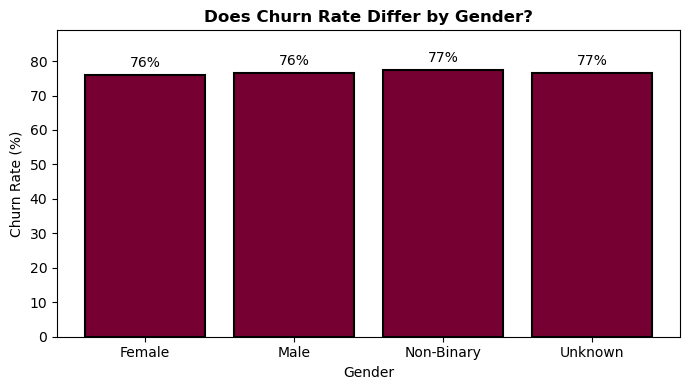

In [53]:
import matplotlib.pyplot as plt

churn_by_gender = (
    df.groupby('Gender')['Churn']
      .mean()
      .mul(100)
      .round(2)
)

plt.figure(figsize=(7, 4))
bars = plt.bar(churn_by_gender.index, churn_by_gender.values,color = '#760031',
                edgecolor='black',
                linewidth=1.5)

# Add value labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (height * 0.02),
        f'{height:.0f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Does Churn Rate Differ by Gender?', fontsize=12, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')

# Add headroom so top labels don't get clipped
plt.ylim(0, max(churn_by_gender.values) * 1.15)

plt.tight_layout()
plt.show()

In [54]:
# Churn rate appears to be very similar across genders, gender not have a strong relationship with customer churn

<h3 style="color:#CC3A63;">Which region has the highest churn rate?</h3>

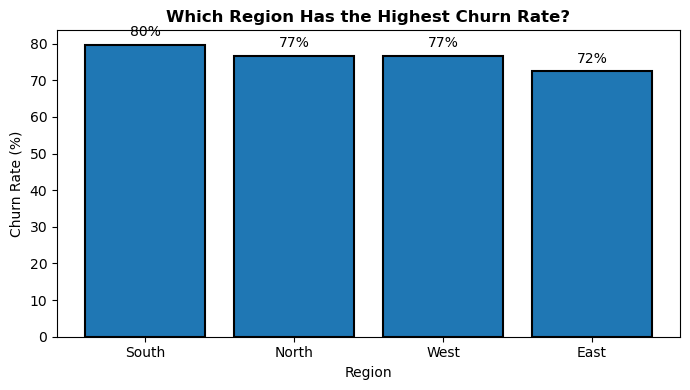

In [55]:
import matplotlib.pyplot as plt

churn_by_region = (
    df.groupby('Region')['Churn']
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))
bars = plt.bar(churn_by_region.index, churn_by_region.values,
                edgecolor='black',
                linewidth=1.5)

# Add value labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + (height * 0.02),
        f'{height:.0f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Which Region Has the Highest Churn Rate?', fontsize=12, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

In [56]:
# The South region has the highest churn rate at 79%, while the East region has the lowest at 72%. 
# churn varies across regions, with the South showing a relatively higher churn rate.

<h3 style="color:#CC3A63;">How does customer age relate to churn?</h3>

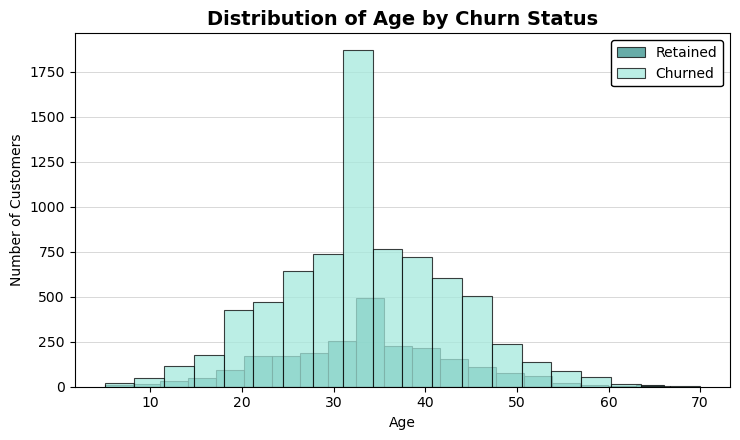

In [57]:
import matplotlib.pyplot as plt

retained_age = df[df.Churn == 0]['Age']
churned_age = df[df.Churn == 1]['Age']

plt.figure(figsize=(7.5, 4.5))

plt.hist(retained_age, bins=20, alpha=0.75, label='Retained',
         color='#34908B', edgecolor='black', linewidth=0.8)
plt.hist(churned_age, bins=20, alpha=0.75, label='Churned',
         color='#A5E9DD', edgecolor='black', linewidth=0.8)

plt.title('Distribution of Age by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.grid(axis='y', color='gray', alpha=0.3, linewidth=0.7)
plt.gca().set_axisbelow(True)  # grid behind bars

plt.legend(frameon=True, edgecolor='black', framealpha=1)

plt.tight_layout()
plt.show()

In [58]:
# The two distributions overlap almost completely and share the same shape and peak
# around age 30-34. Age doesn't separate churners from retained customers in any visible way.

<h2 style="color:#519A66;">6. Dashboard</h2>

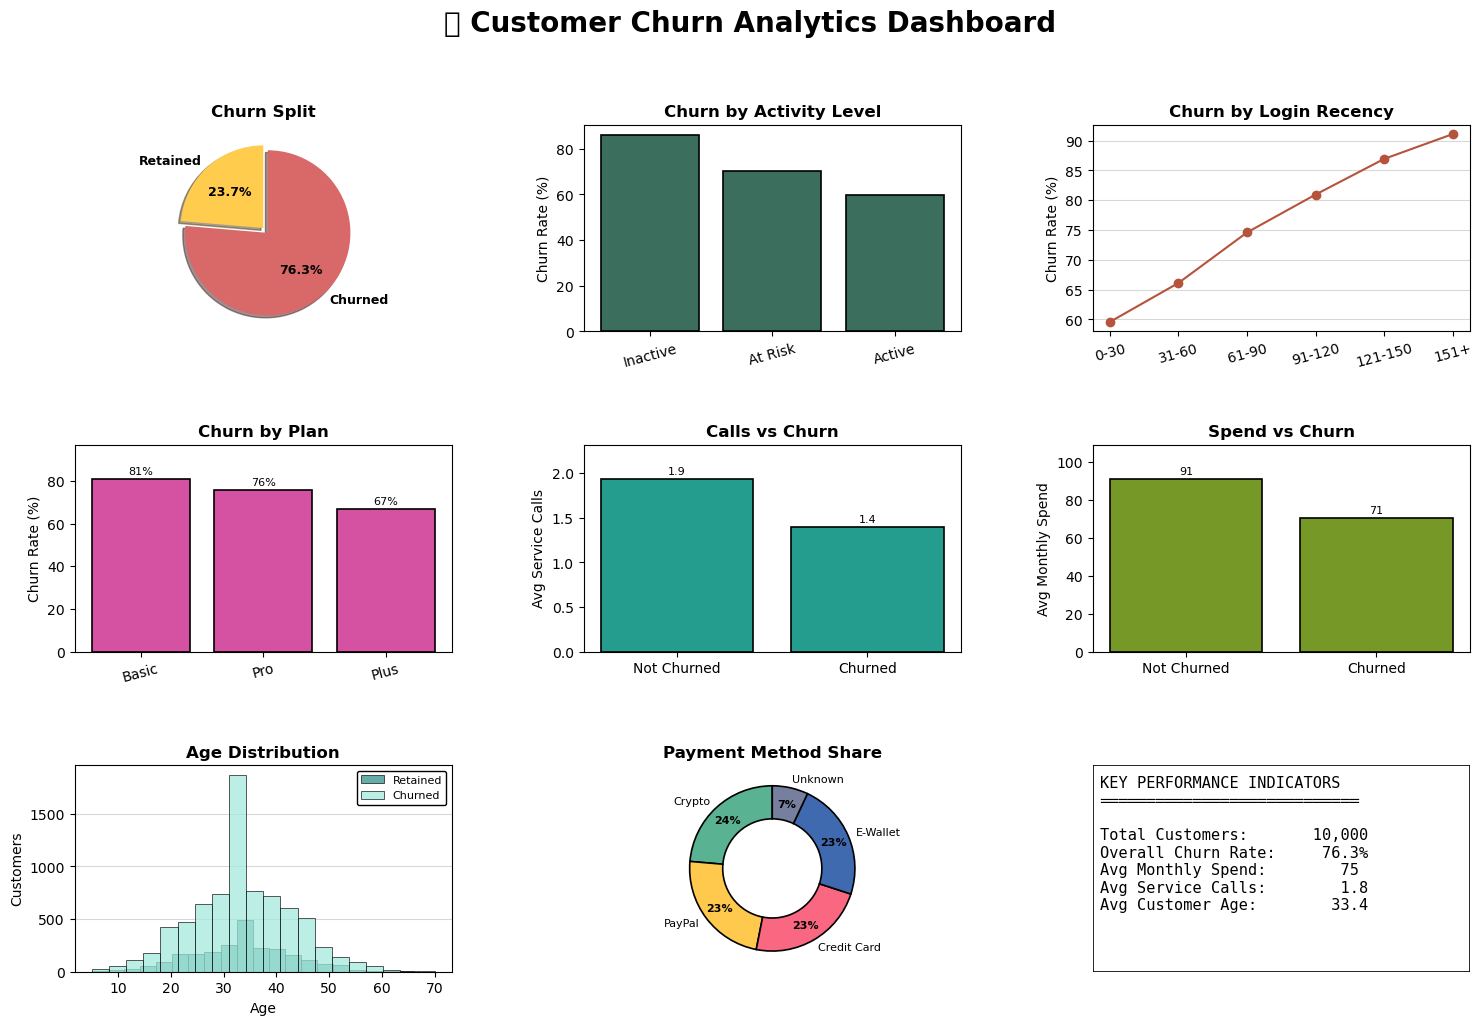

In [59]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# ============================================================
# افترض ان df موجود بالفعل ويحتوي على الاعمدة المطلوبة
# ============================================================

fig = plt.figure(figsize=(18, 11))
fig.suptitle('📊 Customer Churn Analytics Dashboard', fontsize=20, fontweight='bold', y=0.985)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

# ------------------------------------------------------------
# 1) Churn Split (Pie)
# ------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
churn_counts = df['Churn'].value_counts().sort_index()
labels = ['Retained', 'Churned']
colors = ['#FFCC4D', '#D96868']
explode = [0.08 if v == churn_counts.max() else 0 for v in churn_counts.values]

ax1.pie(
    churn_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 9, 'fontweight': 'bold'}
)
ax1.set_title('Churn Split', fontsize=12, fontweight='bold')

# ------------------------------------------------------------
# 2) Churn by Activity Level (Bar)
# ------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
churn_by_activity_level = (
    df.groupby('Login_Activity')['Churn']
      .mean().mul(100).round(2)
      .sort_values(ascending=False)
)
ax2.bar(
    churn_by_activity_level.index,
    churn_by_activity_level.values,
    color='#3C6E5E', edgecolor='black', linewidth=1.2
)
ax2.set_title('Churn by Activity Level', fontsize=12, fontweight='bold')
ax2.set_ylabel('Churn Rate (%)')
ax2.tick_params(axis='x', rotation=15)

# ------------------------------------------------------------
# 3) Churn Rate by Days Since Last Login (Line)
# ------------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])
bins = [-1, 30, 60, 90, 120, 150, 200]
day_labels = ['0-30', '31-60', '61-90', '91-120', '121-150', '151+']
df['days_bucket'] = pd.cut(df['Days_Since_Last_Login'], bins=bins, labels=day_labels)
churn_by_days = (
    df.groupby('days_bucket', observed=True)['Churn']
      .mean().mul(100).round(2)
)
ax3.plot(churn_by_days.index, churn_by_days.values, marker='o', color='#B5533C')
ax3.set_title('Churn by Login Recency', fontsize=12, fontweight='bold')
ax3.set_ylabel('Churn Rate (%)')
ax3.tick_params(axis='x', rotation=15)
ax3.grid(axis='y', color='gray', alpha=0.3)

# ------------------------------------------------------------
# 4) Churn by Subscription Plan (Bar with labels)
# ------------------------------------------------------------
ax4 = fig.add_subplot(gs[1, 0])
churn_by_plan = (
    df.groupby('Subscription_Plan')['Churn']
      .mean().mul(100).round(2)
      .sort_values(ascending=False)
)
bars4 = ax4.bar(churn_by_plan.index, churn_by_plan.values, color='#D552A3',
                 edgecolor='black', linewidth=1.2)
for bar in bars4:
    h = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width() / 2, h + h * 0.02, f'{h:.0f}%',
              ha='center', va='bottom', fontsize=8)
ax4.set_title('Churn by Plan', fontsize=12, fontweight='bold')
ax4.set_ylabel('Churn Rate (%)')
ax4.set_ylim(0, max(churn_by_plan.values) * 1.2)
ax4.tick_params(axis='x', rotation=15)

# ------------------------------------------------------------
# 5) Service Calls vs Churn (Bar with labels)
# ------------------------------------------------------------
ax5 = fig.add_subplot(gs[1, 1])
calls_by_churn = (
    df.groupby('Churn')['Customer_Service_Calls']
      .mean().round(2).sort_values(ascending=False)
)
bars5 = ax5.bar(['Not Churned', 'Churned'], calls_by_churn.values,
                 color='#249D8F', edgecolor='black', linewidth=1.2)
for bar in bars5:
    h = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width() / 2, h + h * 0.02, f'{h:.1f}',
              ha='center', va='bottom', fontsize=8)
ax5.set_title('Calls vs Churn', fontsize=12, fontweight='bold')
ax5.set_ylabel('Avg Service Calls')
ax5.set_ylim(0, max(calls_by_churn.values) * 1.2)

# ------------------------------------------------------------
# 6) Monthly Spend vs Churn (Bar with labels)
# ------------------------------------------------------------
ax6 = fig.add_subplot(gs[1, 2])
spend_by_churn = df.groupby('Churn')['Monthly_Spend'].mean().round(2)
bars6 = ax6.bar(['Not Churned', 'Churned'], spend_by_churn.values,
                 color='#769826', edgecolor='black', linewidth=1.2)
for bar in bars6:
    h = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width() / 2, h + h * 0.02, f'{h:,.0f}',
              ha='center', va='bottom', fontsize=8)
ax6.set_title('Spend vs Churn', fontsize=12, fontweight='bold')
ax6.set_ylabel('Avg Monthly Spend')
ax6.set_ylim(0, max(spend_by_churn.values) * 1.2)

# ------------------------------------------------------------
# 7) Age Distribution by Churn (Histogram)
# ------------------------------------------------------------
ax7 = fig.add_subplot(gs[2, 0])
retained_age = df[df.Churn == 0]['Age']
churned_age = df[df.Churn == 1]['Age']
ax7.hist(retained_age, bins=20, alpha=0.75, label='Retained',
          color='#34908B', edgecolor='black', linewidth=0.6)
ax7.hist(churned_age, bins=20, alpha=0.75, label='Churned',
          color='#A5E9DD', edgecolor='black', linewidth=0.6)
ax7.set_title('Age Distribution', fontsize=12, fontweight='bold')
ax7.set_xlabel('Age')
ax7.set_ylabel('Customers')
ax7.grid(axis='y', color='gray', alpha=0.3)
ax7.set_axisbelow(True)
ax7.legend(frameon=True, edgecolor='black', framealpha=1, fontsize=8)

# ------------------------------------------------------------
# 8) Payment Method Share (Donut, no logo for dashboard view)
# ------------------------------------------------------------
ax8 = fig.add_subplot(gs[2, 1])
payment_counts = df['Payment_Method'].value_counts()
wedges8, _ = ax8.pie(
    payment_counts.values,
    labels=payment_counts.index,
    startangle=90,
    colors=['#59B292', '#FFC94D', '#FA6781', '#406AAF', '#767F9E'],
    wedgeprops={'width': 0.4, 'edgecolor': 'black', 'linewidth': 1.2},
    labeldistance=1.1,
    textprops={'fontsize': 8}
)
total8 = payment_counts.sum()
for wedge, value in zip(wedges8, payment_counts.values):
    pct = value / total8 * 100
    angle = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)
    x, y = np.cos(angle), np.sin(angle)
    ax8.annotate(f'{pct:.0f}%', xy=(x * 0.8, y * 0.8), fontsize=8,
                 fontweight='bold', ha='center', va='center')
ax8.set_title('Payment Method Share', fontsize=12, fontweight='bold')

# ------------------------------------------------------------
# 9) KPI Summary Panel
# ------------------------------------------------------------
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

total_customers = len(df)
churn_rate_overall = df['Churn'].mean() * 100
avg_spend = df['Monthly_Spend'].mean()
avg_age = df['Age'].mean()
avg_calls = df['Customer_Service_Calls'].mean()

kpi_text = (
    "KEY PERFORMANCE INDICATORS\n"
    "════════════════════════════\n\n"
    f"Total Customers:      {total_customers:>7,}\n"
    f"Overall Churn Rate:   {churn_rate_overall:>6.1f}%\n"
    f"Avg Monthly Spend:  {avg_spend:>8,.0f}\n"
    f"Avg Service Calls:    {avg_calls:>7.1f}\n"
    f"Avg Customer Age:     {avg_age:>7.1f}\n"
)
ax9.text(0.02, 0.95, kpi_text, fontsize=11, family='monospace',
          va='top', ha='left', transform=ax9.transAxes)
ax9.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='black',
                             linewidth=1.2, transform=ax9.transAxes))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('churn_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

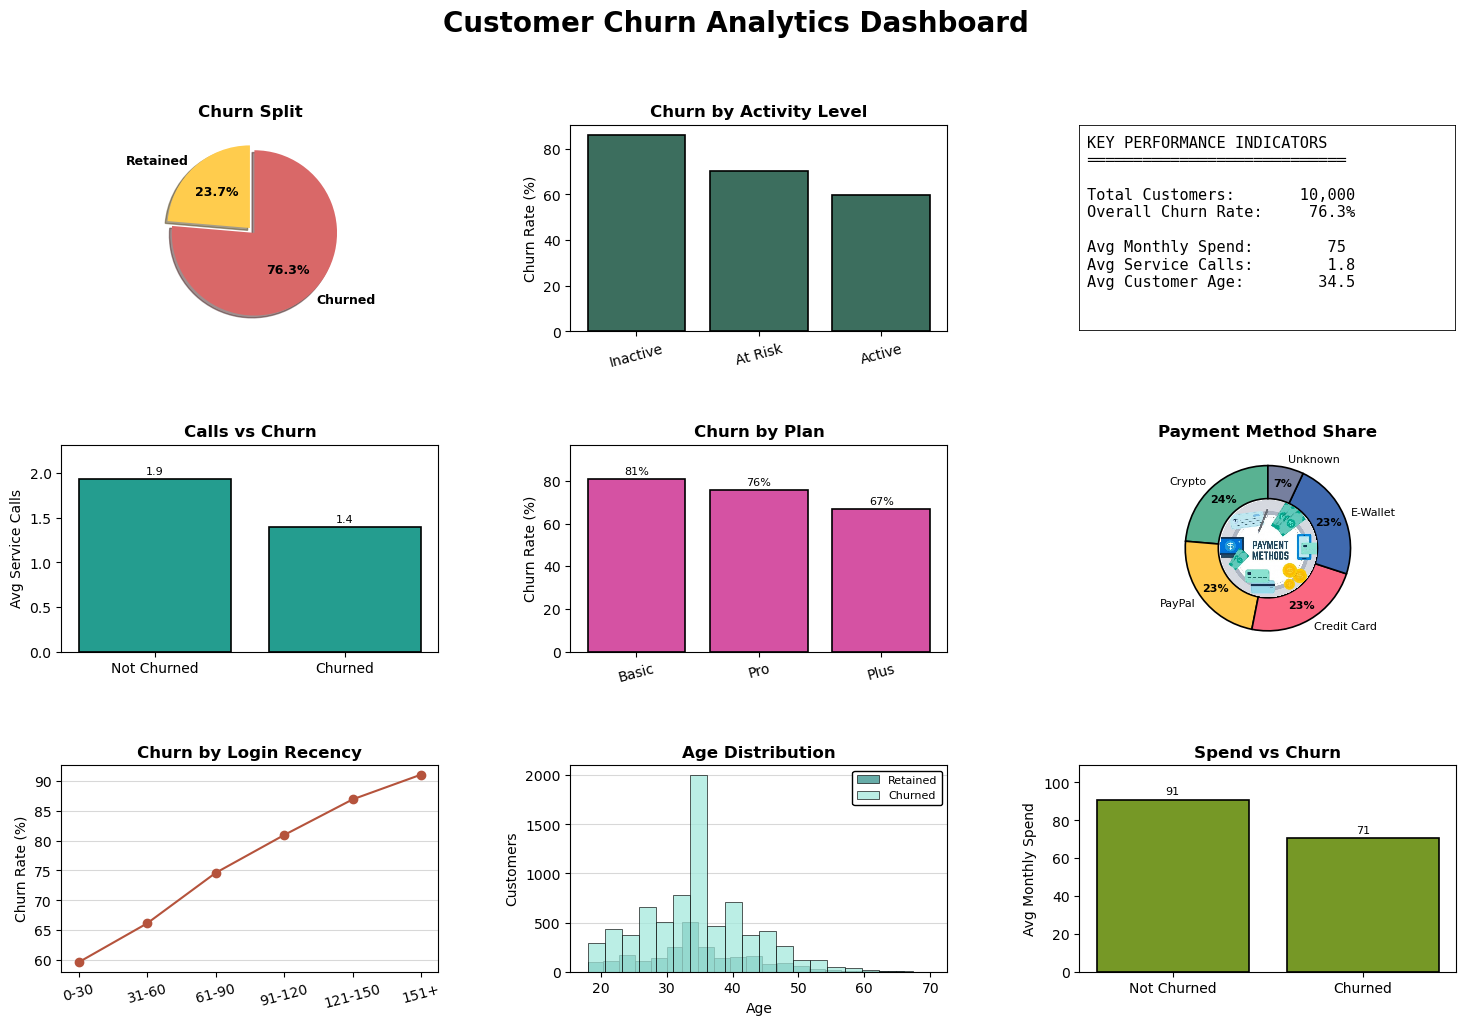

In [75]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

fig = plt.figure(figsize=(18, 11))
fig.suptitle('Customer Churn Analytics Dashboard', fontsize=20, fontweight='bold', y=0.985)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

# ------------------------------------------------------------
# [0,0] Churn Split (Pie)
# ------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
churn_counts = df['Churn'].value_counts().sort_index()
labels = ['Retained', 'Churned']
colors = ['#FFCC4D', '#D96868']
explode = [0.08 if v == churn_counts.max() else 0 for v in churn_counts.values]

ax1.pie(
    churn_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 9, 'fontweight': 'bold'}
)
ax1.set_title('Churn Split', fontsize=12, fontweight='bold')

# ------------------------------------------------------------
# [0,1] Churn by Activity Level (Bar)
# ------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
churn_by_activity_level = (
    df.groupby('Login_Activity')['Churn']
      .mean().mul(100).round(2)
      .sort_values(ascending=False)
)
ax2.bar(
    churn_by_activity_level.index,
    churn_by_activity_level.values,
    color='#3C6E5E', edgecolor='black', linewidth=1.2
)
ax2.set_title('Churn by Activity Level', fontsize=12, fontweight='bold')
ax2.set_ylabel('Churn Rate (%)')
ax2.tick_params(axis='x', rotation=15)

# ------------------------------------------------------------
# [0,2] KPI Summary Panel
# ------------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')

total_customers = len(df)
churn_rate_overall = df['Churn'].mean() * 100
avg_spend = df['Monthly_Spend'].mean()
avg_age = df['Age'].mean()
avg_calls = df['Customer_Service_Calls'].mean()

kpi_text = (
    "KEY PERFORMANCE INDICATORS\n"
    "════════════════════════════\n\n"
    f"Total Customers:      {total_customers:>7,}\n"
    f"Overall Churn Rate:   {churn_rate_overall:>6.1f}%\n\n"
    f"Avg Monthly Spend:  {avg_spend:>8,.0f}\n"
    f"Avg Service Calls:    {avg_calls:>7.1f}\n"
    f"Avg Customer Age:     {avg_age:>7.1f}\n"
)
ax3.text(0.02, 0.95, kpi_text, fontsize=11, family='monospace',
          va='top', ha='left', transform=ax3.transAxes)
ax3.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor='black',
                             linewidth=1.2, transform=ax3.transAxes))

# ------------------------------------------------------------
# [1,0] Calls vs Churn (Bar with labels)
# ------------------------------------------------------------
ax4 = fig.add_subplot(gs[1, 0])
calls_by_churn = (
    df.groupby('Churn')['Customer_Service_Calls']
      .mean().round(2).sort_values(ascending=False)
)
bars4 = ax4.bar(['Not Churned', 'Churned'], calls_by_churn.values,
                 color='#249D8F', edgecolor='black', linewidth=1.2)
for bar in bars4:
    h = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width() / 2, h + h * 0.02, f'{h:.1f}',
              ha='center', va='bottom', fontsize=8)
ax4.set_title('Calls vs Churn', fontsize=12, fontweight='bold')
ax4.set_ylabel('Avg Service Calls')
ax4.set_ylim(0, max(calls_by_churn.values) * 1.2)

# ------------------------------------------------------------
# [1,1] Churn by Plan (Bar with labels)
# ------------------------------------------------------------
ax5 = fig.add_subplot(gs[1, 1])
churn_by_plan = (
    df.groupby('Subscription_Plan')['Churn']
      .mean().mul(100).round(2)
      .sort_values(ascending=False)
)
bars5 = ax5.bar(churn_by_plan.index, churn_by_plan.values, color='#D552A3',
                 edgecolor='black', linewidth=1.2)
for bar in bars5:
    h = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width() / 2, h + h * 0.02, f'{h:.0f}%',
              ha='center', va='bottom', fontsize=8)
ax5.set_title('Churn by Plan', fontsize=12, fontweight='bold')
ax5.set_ylabel('Churn Rate (%)')
ax5.set_ylim(0, max(churn_by_plan.values) * 1.2)
ax5.tick_params(axis='x', rotation=15)

# ------------------------------------------------------------
# [1,2] Payment Method Share (Donut with logo in center)
# ------------------------------------------------------------
ax6 = fig.add_subplot(gs[1, 2])
payment_counts = df['Payment_Method'].value_counts()
wedges6, _ = ax6.pie(
    payment_counts.values,
    labels=payment_counts.index,
    startangle=90,
    colors=['#59B292', '#FFC94D', '#FA6781', '#406AAF', '#767F9E'],
    wedgeprops={'width': 0.4, 'edgecolor': 'black', 'linewidth': 1.2},
    labeldistance=1.1,
    textprops={'fontsize': 8}
)
total6 = payment_counts.sum()
for wedge, value in zip(wedges6, payment_counts.values):
    pct = value / total6 * 100
    angle = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)
    x, y = np.cos(angle), np.sin(angle)
    ax6.annotate(f'{pct:.0f}%', xy=(x * 0.8, y * 0.8), fontsize=8,
                 fontweight='bold', ha='center', va='center')

# --- put the payment-methods logo image in the donut hole ---
try:
    logo = Image.open('payment-methods.jpg').convert('RGBA')
    size = min(logo.size)
    left = (logo.width - size) // 2
    top = (logo.height - size) // 2
    logo = logo.crop((left, top, left + size, top + size))

    mask = Image.new('L', logo.size, 0)
    draw = ImageDraw.Draw(mask)
    draw.ellipse((0, 0, logo.width, logo.height), fill=255)
    logo.putalpha(mask)

    logo_array = np.array(logo)
    imagebox = OffsetImage(logo_array, zoom=0.14)
    ab = AnnotationBbox(imagebox, (0, 0), frameon=False, box_alignment=(0.5, 0.5))
    ax6.add_artist(ab)
except FileNotFoundError:
    # لو الملف مش موجود، السكريبت يكمل عادي من غير اللوجو
    pass

ax6.set_title('Payment Method Share', fontsize=12, fontweight='bold')
ax6.set_aspect('equal')

# ------------------------------------------------------------
# [2,0] Churn by Login Recency (Line)
# ------------------------------------------------------------
ax7 = fig.add_subplot(gs[2, 0])
bins = [-1, 30, 60, 90, 120, 150, 200]
day_labels = ['0-30', '31-60', '61-90', '91-120', '121-150', '151+']
df['days_bucket'] = pd.cut(df['Days_Since_Last_Login'], bins=bins, labels=day_labels)
churn_by_days = (
    df.groupby('days_bucket', observed=True)['Churn']
      .mean().mul(100).round(2)
)
ax7.plot(churn_by_days.index, churn_by_days.values, marker='o', color='#B5533C')
ax7.set_title('Churn by Login Recency', fontsize=12, fontweight='bold')
ax7.set_ylabel('Churn Rate (%)')
ax7.tick_params(axis='x', rotation=15)
ax7.grid(axis='y', color='gray', alpha=0.3)

# ------------------------------------------------------------
# [2,1] Age Distribution by Churn (Histogram)
# ------------------------------------------------------------
ax8 = fig.add_subplot(gs[2, 1])
retained_age = df[df.Churn == 0]['Age']
churned_age = df[df.Churn == 1]['Age']
ax8.hist(retained_age, bins=20, alpha=0.75, label='Retained',
          color='#34908B', edgecolor='black', linewidth=0.6)
ax8.hist(churned_age, bins=20, alpha=0.75, label='Churned',
          color='#A5E9DD', edgecolor='black', linewidth=0.6)
ax8.set_title('Age Distribution', fontsize=12, fontweight='bold')
ax8.set_xlabel('Age')
ax8.set_ylabel('Customers')
ax8.grid(axis='y', color='gray', alpha=0.3)
ax8.set_axisbelow(True)
ax8.legend(frameon=True, edgecolor='black', framealpha=1, fontsize=8)

# ------------------------------------------------------------
# [2,2] Spend vs Churn (Bar with labels)
# ------------------------------------------------------------
ax9 = fig.add_subplot(gs[2, 2])
spend_by_churn = df.groupby('Churn')['Monthly_Spend'].mean().round(2)
bars9 = ax9.bar(['Not Churned', 'Churned'], spend_by_churn.values,
                 color='#769826', edgecolor='black', linewidth=1.2)
for bar in bars9:
    h = bar.get_height()
    ax9.text(bar.get_x() + bar.get_width() / 2, h + h * 0.02, f'{h:,.0f}',
              ha='center', va='bottom', fontsize=8)
ax9.set_title('Spend vs Churn', fontsize=12, fontweight='bold')
ax9.set_ylabel('Avg Monthly Spend')
ax9.set_ylim(0, max(spend_by_churn.values) * 1.2)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('churn_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()